# Example: Downloading datasets from the Climate Data Store with the `cdsapi`

## The Climate Data Store

The Climate Data Store (CDS) provides free open access to information about the past, present and future climate, including observations, historical records, reanalyses, forecasts, and projections. The CDS can be accessed online at <https://cds.climate.copernicus.eu/> or programmatically using the `cdsapi` Python package.

## Installing and configuring the `cdsapi` package

To run this example, you need a CDS account and your API key (personal access token), which is available from <https://cds.climate.copernicus.eu/how-to-api>.

Please enter your API key to configure the `cdsapi.Client` in the next cell.

Please remember that you must keep your API key private and should not share a notebook that contains your personal API key.

In [1]:
import getpass

import cdsapi

client = cdsapi.Client(
    url="https://cds.climate.copernicus.eu/api",
    key=getpass.getpass("CDS-API-KEY: "),
)

CDS-API-KEY:  ········


## Retrieving the dataset

You can now retrieve the following example NetCDF dataset.

```{tip}
Retrieving a dataset from the Climate Data Store may take a long time to process, ranging from minutes to hours, as data requests are served on the fly using a queueing system. If you intend to reuse a dataset several times, consider downloading it to your local machine instead of fetching it from the CDS every time.
```

Once the download has completed, you should have a new `03-t2m.nc` file in the `data/` subdirectory.

In [2]:
from pathlib import Path

req = client.retrieve(
    "reanalysis-era5-single-levels",
    {
        "variable": "2t",
        "product_type": "reanalysis",
        "date": "2012-12-01",
        "time": "14:00",
        "format": "netcdf",
    },
)

data_path = req.download(Path("data") / "03-t2m.nc")

2026-09-08 09:02:44,021 INFO Request ID is 0a8c93bf-0337-4c5d-9ab4-a4d961ba8f88
2026-09-08 09:02:47,623 INFO status has been updated to accepted
2026-09-08 09:03:02,917 INFO status has been updated to running
2026-09-08 09:03:10,601 INFO status has been updated to successful


d36bc855f88f6b3ebca76b2d3dcfcdb9.nc:   0%|          | 0.00/1.46M [00:00<?, ?B/s]

In [3]:
import xarray as xr

ds = xr.open_dataset(data_path)
ds

<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2012-12-01T14:00:00
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-18T11:06 GRIB to CDM+CF via cfgrib-0.9.1...

## Plotting the dataset

In [4]:
import sys

sys.path.insert(0, "../..")

In [5]:
import utils

We finally plot the loaded dataset, here the 2 metre temperature variable `t2m`, using `earthkit.plots`:

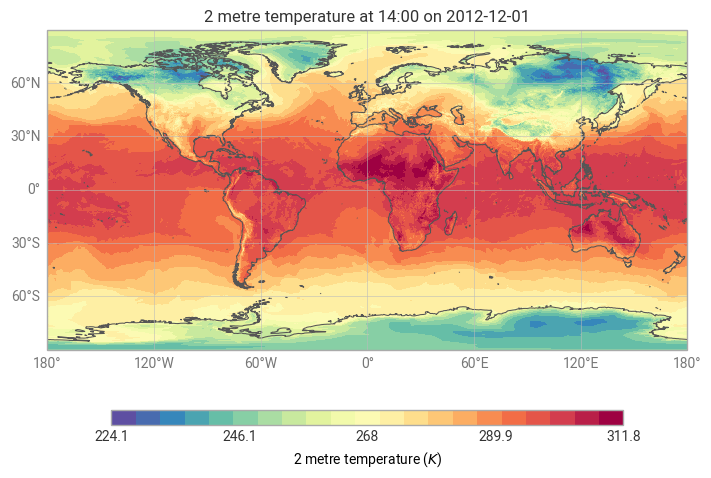

In [6]:
utils.quickplot(ds["t2m"])